# 数据可视化

数据可视化是将数据转换为图形表示的过程，以便更容易理解和分析。它通过图表、图形和其他视觉手段呈现数据，使复杂的信息更直观。数据可视化对理解数据特征、发现模式、发现异常值、预测趋势、发现关联性等有着重要作用。

本项目中，我们将使用Matplotlib库和Seaborn库进行数据可视化。Matplotlib是一个Python的2D绘图库，可用于创建各种类型的图表，如折线图、散点图、直方图、饼图等。其文档官网为`https://matplotlib.org/stable/index.html`。Seaborn库是基于Matplotlib的高级数据可视化库，它提供了更高级的图表类型，如热力图、小提琴图、分布图等。其文档官网为`https://seaborn.pydata.org/index.html`。

In [18]:
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import json
import math

plt.rcParams['font.sans-serif'] = ["Noto Sans CJK JP"]  # 正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [19]:
dataset_paths = {
    '激光载荷': '../../data/train/激光载荷',
    '供配电': '../../data/train/供配电', 
    '姿轨控': '../../data/train/姿轨控'
}

可视化的时候发现一些warning，一些特征列按照正常和故障划分之后变成单一值，没有分布

这说明这些值与故障和正常强相关，我们可以直接利用这些单一值进行故障诊断。先找出这些值：

In [20]:
def find_single_value_columns(df):
    """
        查找数据集中只有划分后某一类（正常或故障）具有单一值的列。
        返回两个字典，分别包含只有单一值的正常数据列和故障
    """
    all_normal = {'col': 'value'}
    all_fault = {'col': 'value'}

    for column in df.columns:
        if df.loc[df['label'] == 0, column].nunique() == 1:
            all_normal[column] = df.loc[df['label'] == 0, column].iloc[0]
        elif df.loc[df['label'] != 0, column].nunique() == 1:
            all_fault[column] = df.loc[df['label'] != 0, column].iloc[0]

    return all_normal, all_fault

In [21]:
for dataset_name, path in dataset_paths.items():
    print(f"\n==={dataset_name}===")
    df = pd.read_csv(os.path.join(path, 'processed_all.csv'))
    all_normal, all_fault = find_single_value_columns(df)
    print(f"只有单一值的正常数据列:")
    for col, val in all_normal.items():
        print(f" {col}: {val}")
        
    print(f"只有单一值的故障数据列")
    for col, val in all_fault.items():
        print(f" {col}: {val}")


===激光载荷===
只有单一值的正常数据列:
 col: value
 EDFA主放（主）故障状态自检反馈: 0
 label: 0
只有单一值的故障数据列
 col: value
 激光处理机最后一条接收指令编号: 4
 激光终端处理机供电电压: 42
 模块工作状态-转台: 0
 转台方位轴控温点1: 1
 转台方位轴控温点2: 1
 转台高度轴控温点1: 1
 转台高度轴控温点2: 1
 光学基板控温点1: 1
 光学基板控温点2: 1
 光学基板控温点3: 1
 可见光图像传感器光斑Y坐标: 0
 转台方位轴测温点1: 18
 转台高度轴测温点1: 20
 转台高度轴测温点2: 22
 光学基板测温点1: 24
 光学基板测温点2: 20

===供配电===
只有单一值的正常数据列:
 col: value
 蓄电池加热器2通断状态: 1
 蓄电池加热器3通断状态: 1
 -Y板加热器1通断状态: 1
 -Y板加热器2通断状态: 1
 -Y板加热器3通断状态: 1
 label: 0
只有单一值的故障数据列
 col: value

===姿轨控===
只有单一值的正常数据列:
 col: value
 平衡方程满足标志: 1
 label: 0
只有单一值的故障数据列
 col: value
 子模式_入轨段控制模式: 1
 正Y翼B轴控制模式: 2
 负Y翼B轴控制模式: 2
 冷气推力器1控制脉宽: 0.0
 冷气推力器2控制脉宽: 0.0
 冷气推力器3控制脉宽: 0.0
 冷气推力器4控制脉宽: 0.0
 陀螺3有效性标志: 1
 陀螺4有效性标志: 1
 星敏1工作模式: 1
 星敏2工作模式: 1
 星敏3工作模式: 1
 电推工作模式: 0


In [22]:
def visulize(name, df):
    """
        对数据中每个特征，分别绘制正常数据和故障数据的分布图
    """ 

    target_fault = df['label'] != 0 # 可以修改为特定的故障类型来查看
    normal = df['label'] == 0

    cols = 6
    rows = (df.shape[1] + cols - 1) // cols
    plt.figure(figsize=(20, 4 * rows))

    for i, column in enumerate(df.columns):
        if column == 'label':
           continue

        # 绘制分布图
        ax = plt.subplot(rows, cols, i + 1)
        sns.kdeplot(df.loc[normal, column], label='正常', color='blue', fill=True, ax=ax)
        sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
        ax.set_title(f"{name} - {column} 分布")
        ax.legend()

    plt.tight_layout()
    plt.show()


=== 可视化 激光载荷 数据集 ===


/tmp/ipykernel_22732/2997427981.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.

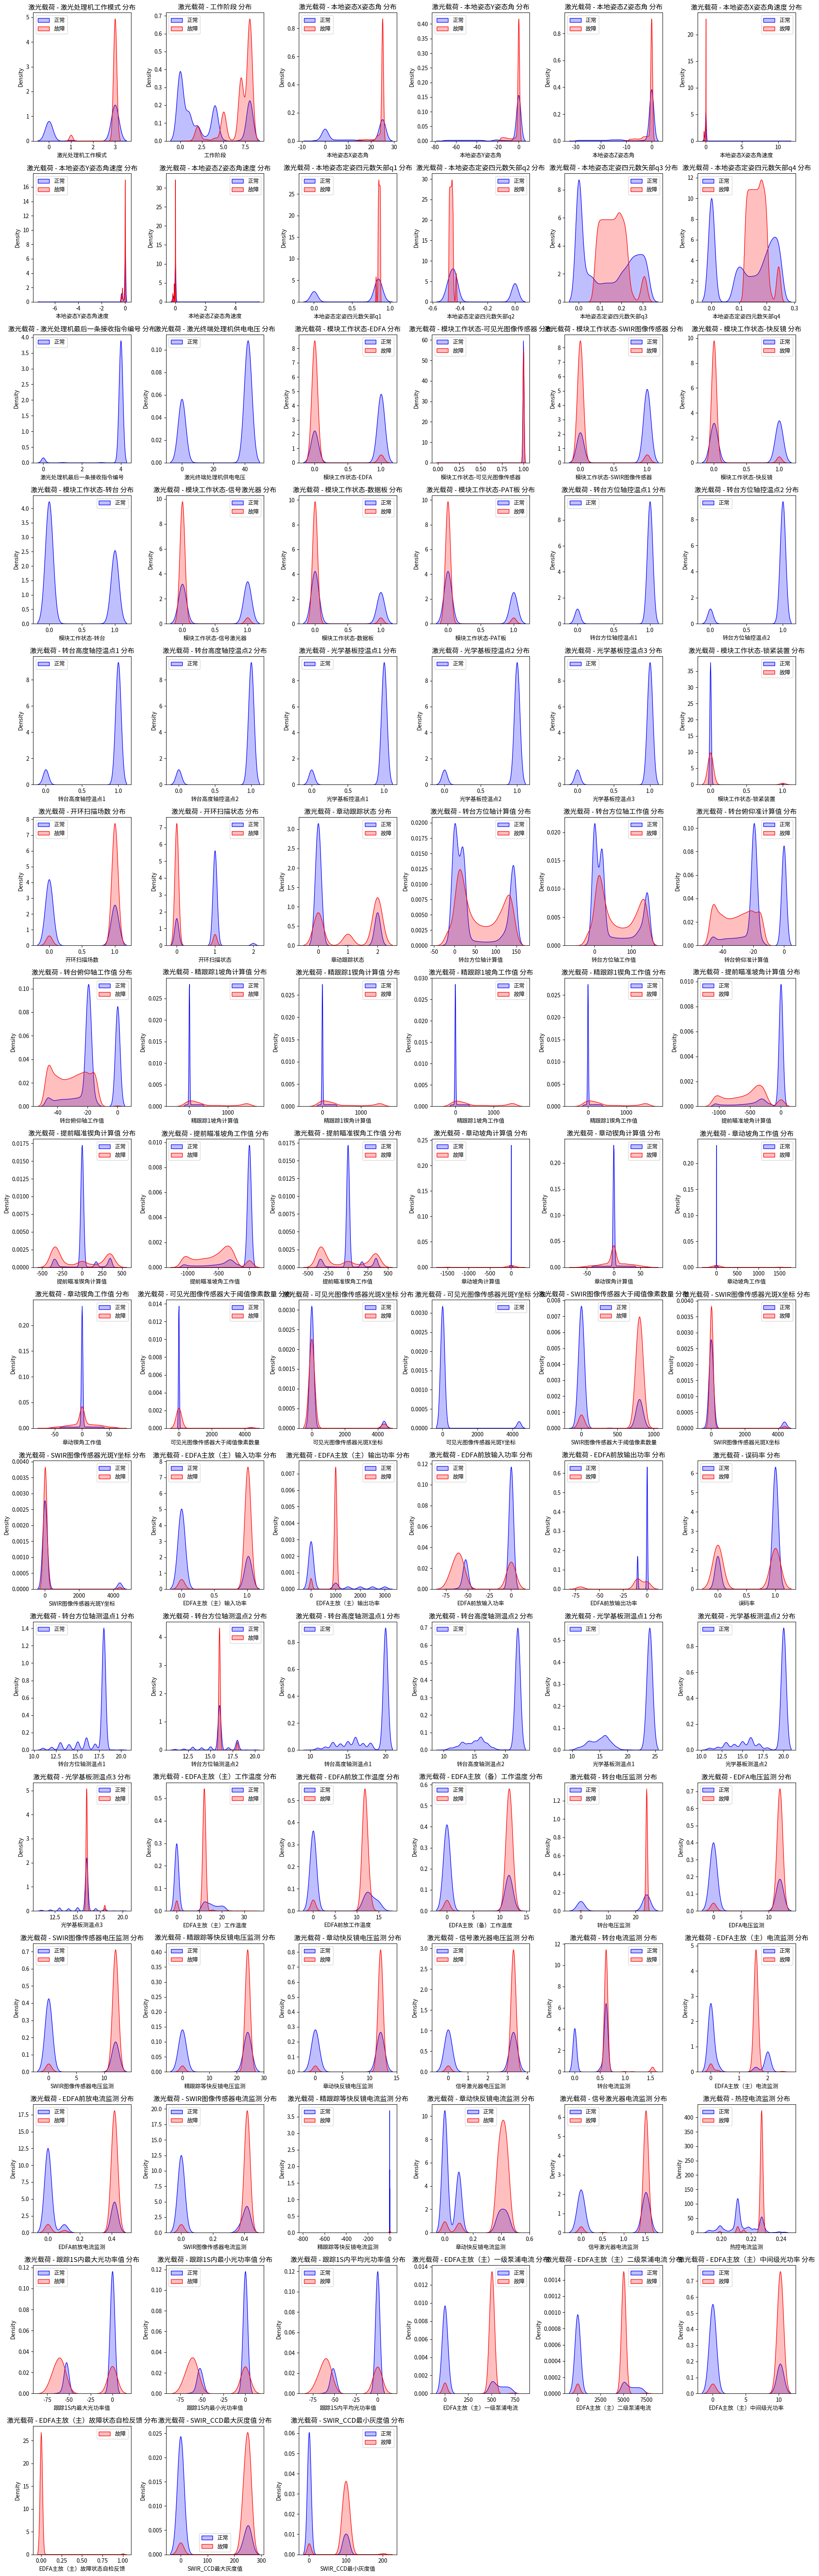


=== 可视化 供配电 数据集 ===


/tmp/ipykernel_22732/2997427981.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[normal, column], label='正常', color='blue', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[normal, column], label='正常', color='blue', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[normal, column], label='正常', color='blue', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[normal, column], label='正常', color='blue', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:19: UserWarning: 

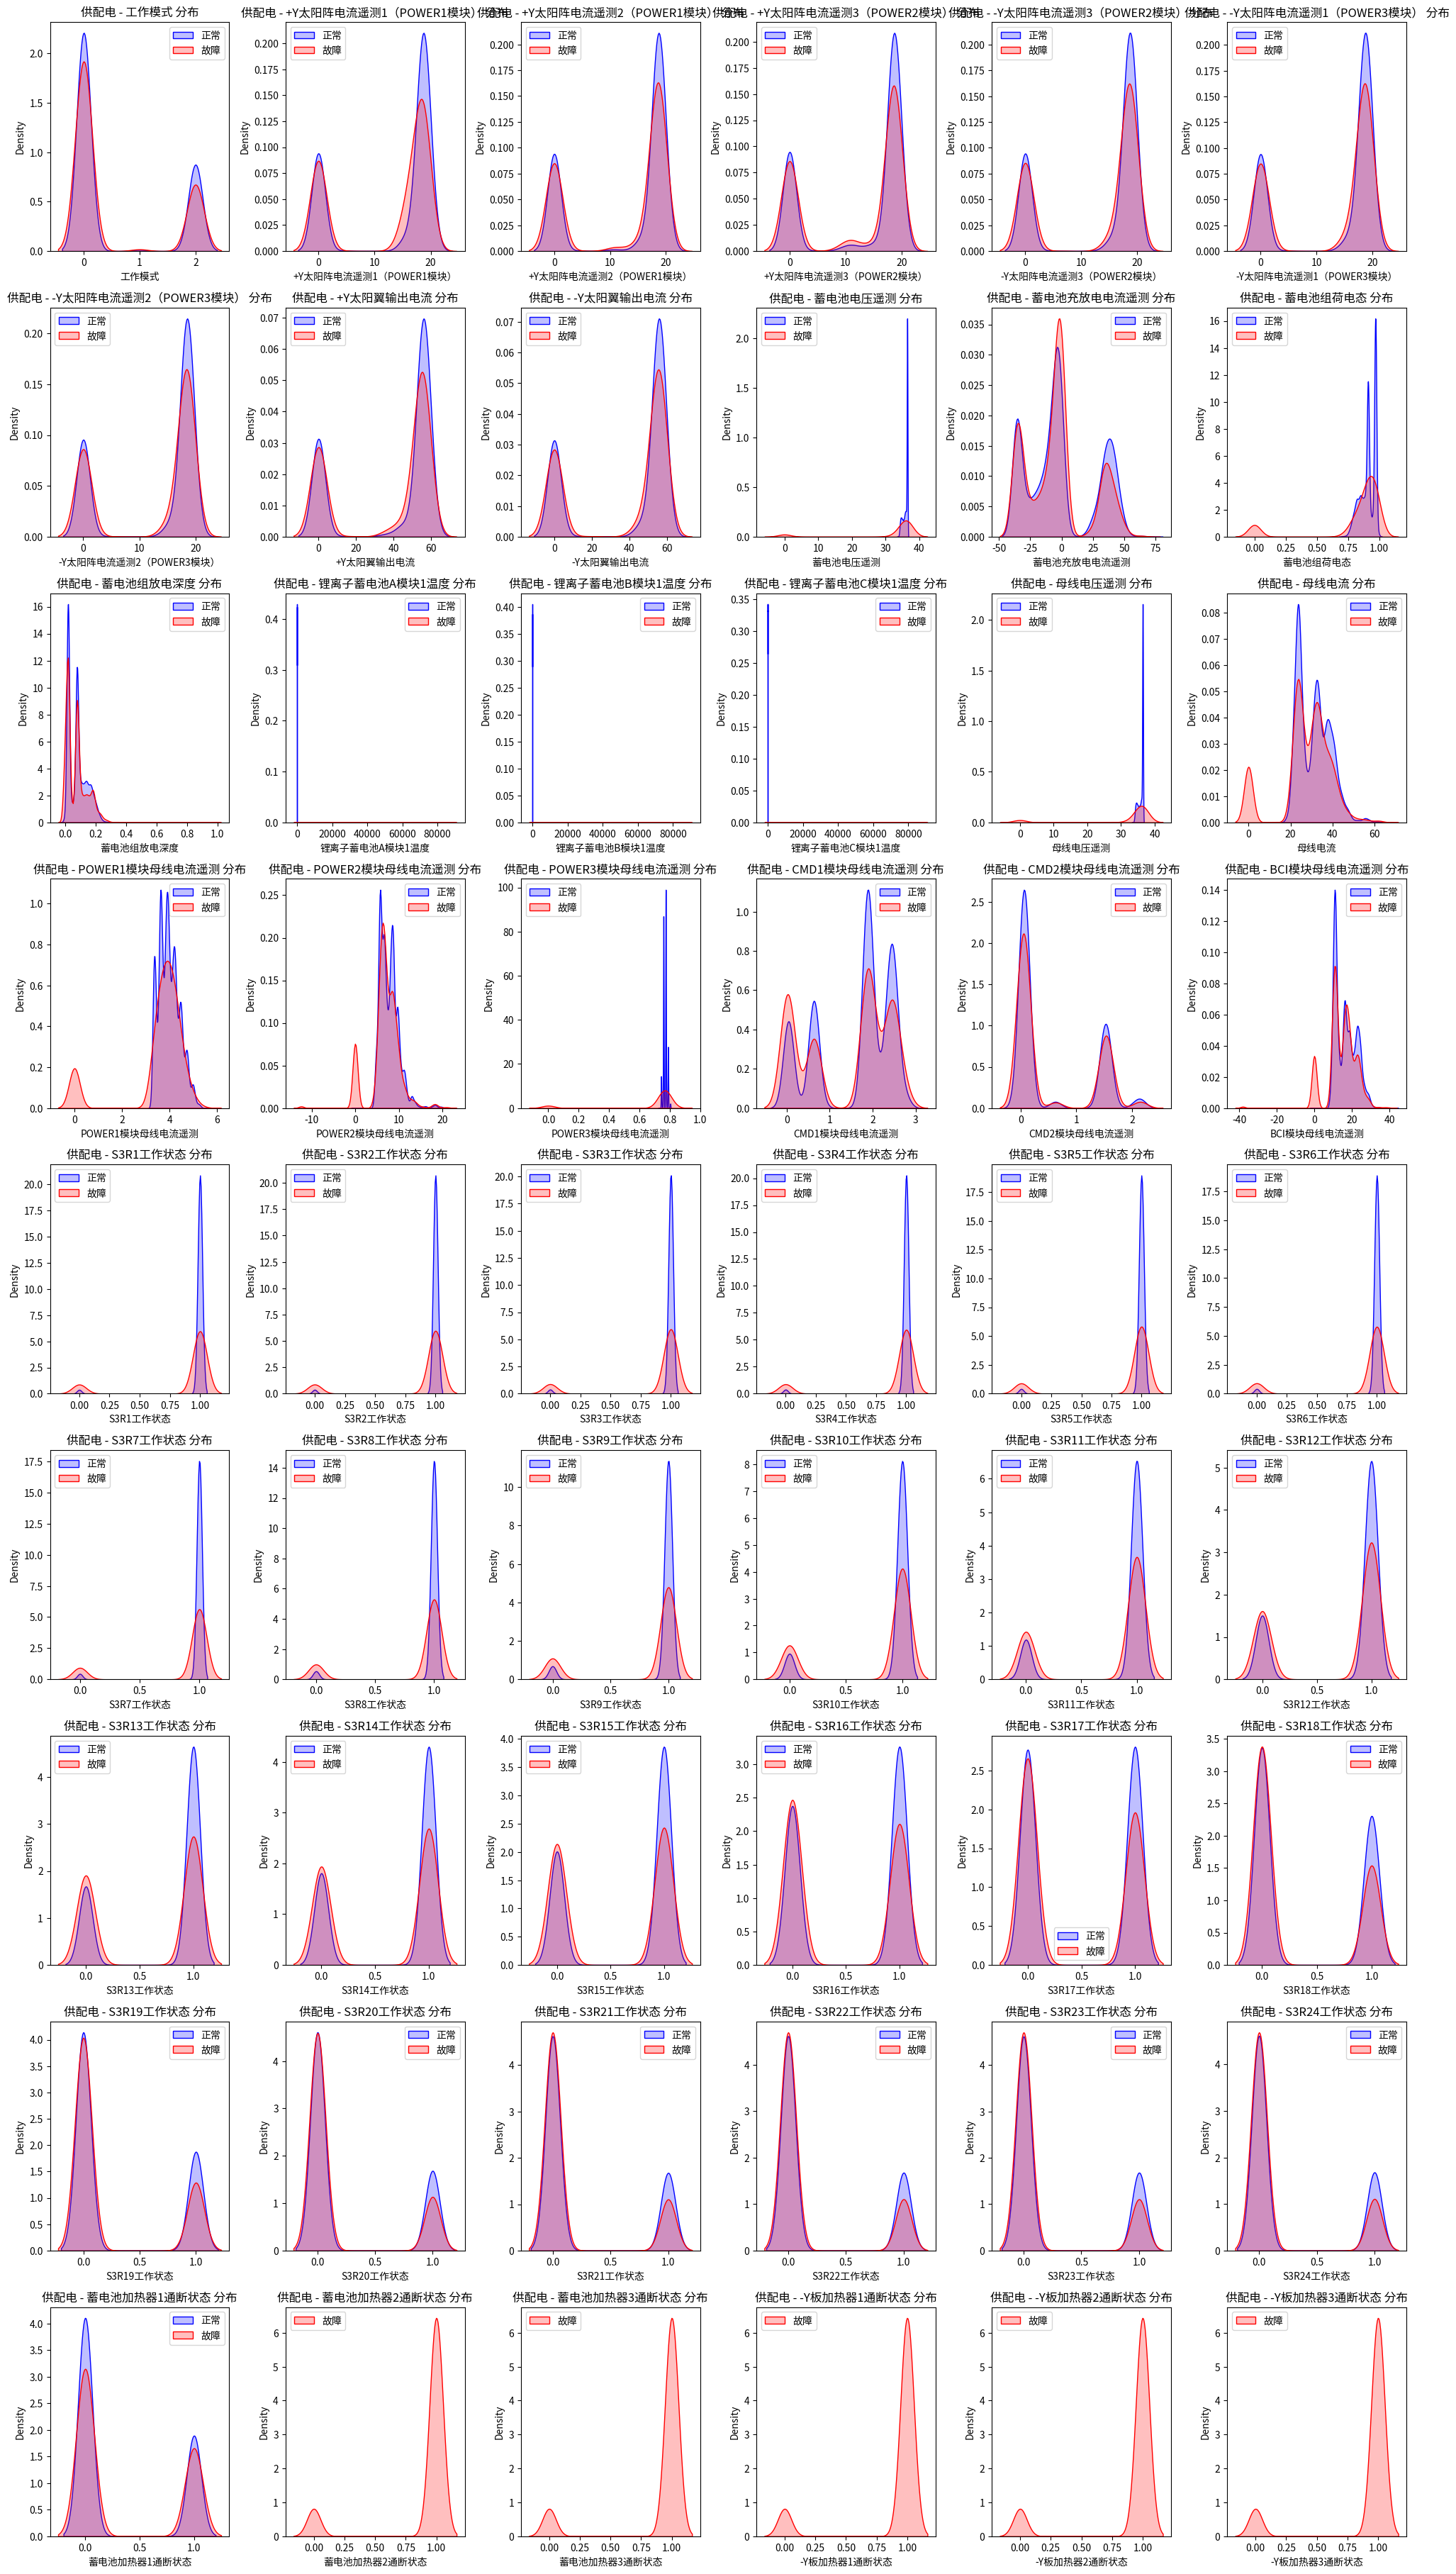


=== 可视化 姿轨控 数据集 ===


/tmp/ipykernel_22732/2997427981.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df.loc[target_fault, column], label='故障', color='red', fill=True, ax=ax)
/tmp/ipykernel_22732/2997427981.

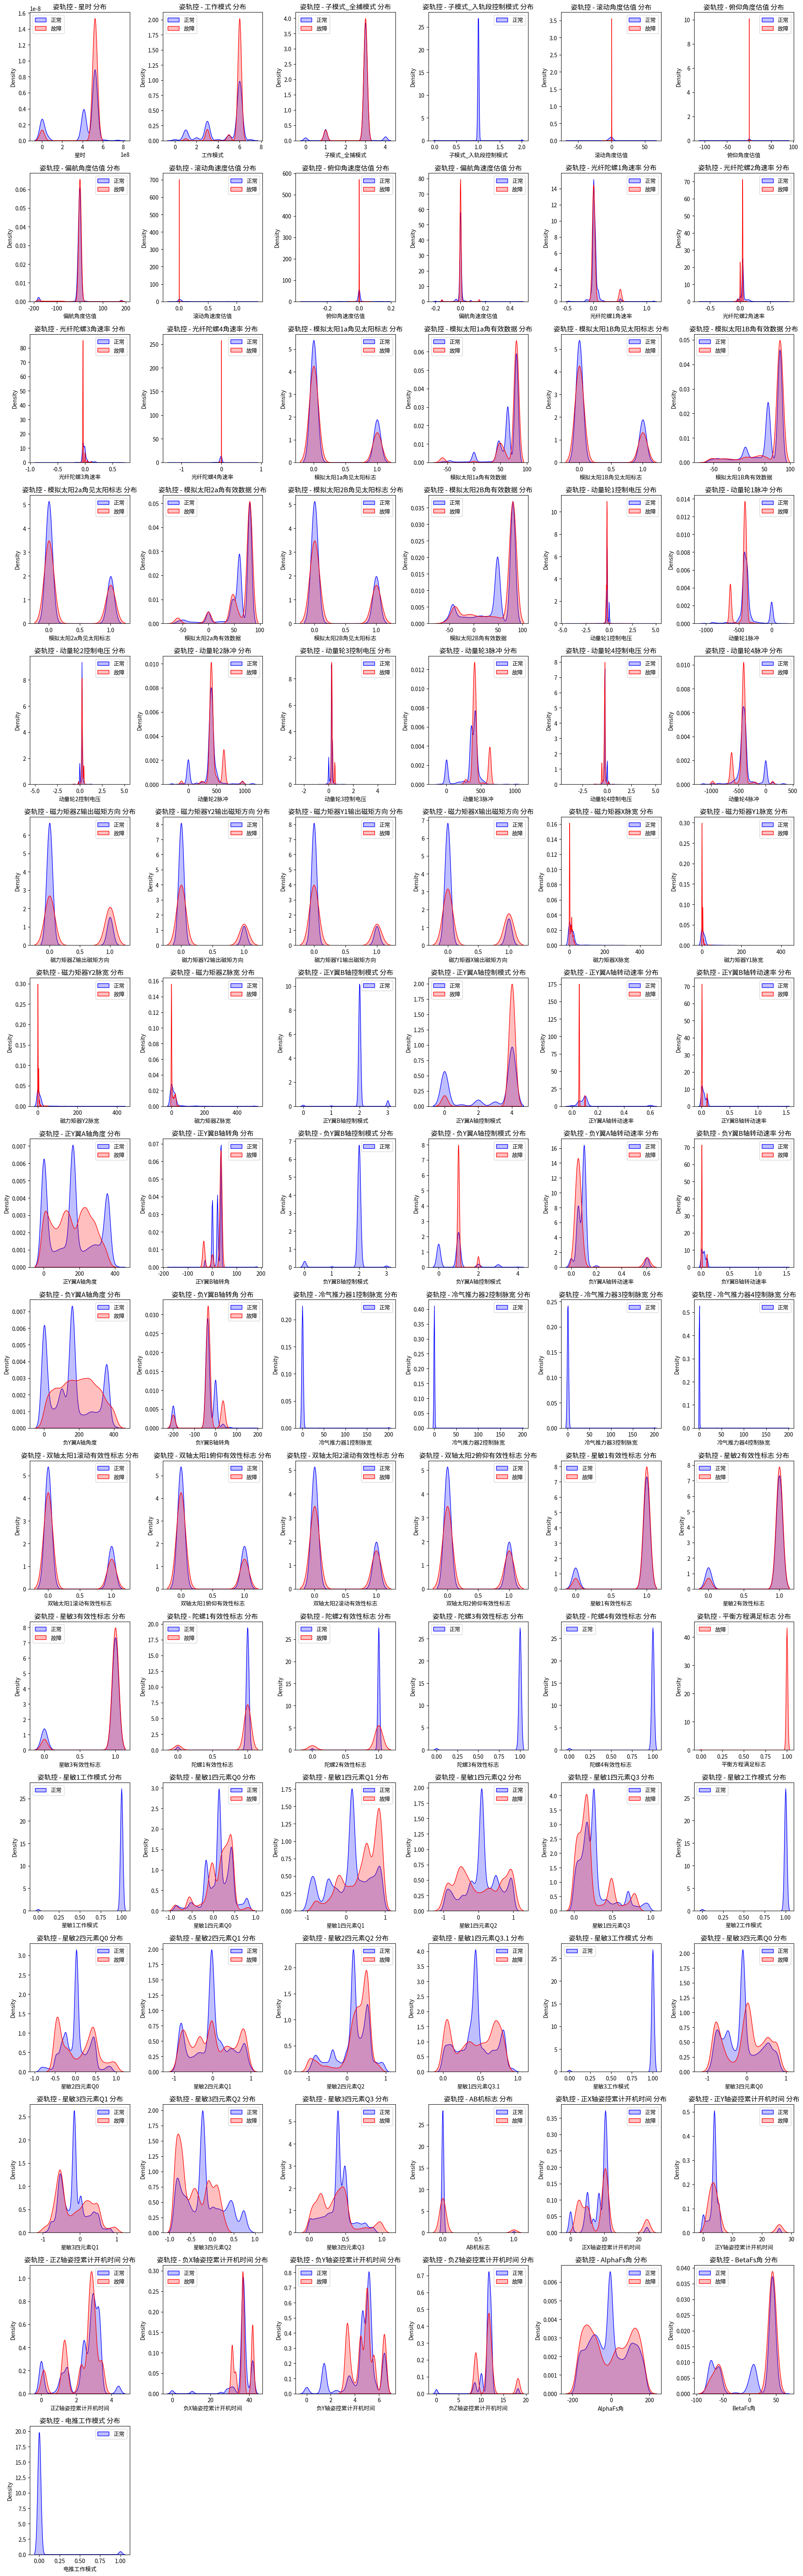

In [23]:
for dataset_name, path in dataset_paths.items():
    print(f"\n=== 可视化 {dataset_name} 数据集 ===")
    df = pd.read_csv(os.path.join(path, 'processed_all.csv'))
    visulize(dataset_name, df)

In [35]:
def visulize_target_label(df, dataset_name, target_fault_names):
    """
    在同一张图上比较多个故障类型与正常数据的特征分布。

    参数：
      df: pandas.DataFrame, 包含 'label' 列
      dataset_name: str, 用于定位 '../../data/{dataset_name}/itoa.json' 和 atoi.json
      target_fault_names: list or None, 要比较的故障类型，可以是 label(int/str) 列表，或者是 itoa 中的中文名称列表；
                         如果为 None，则使用所有非零 label。
    """
    with open(f'../../data/train/{dataset_name}/itoa.json', 'r') as f:
        itoa = json.load(f)

    with open(f'../../data/train/{dataset_name}/atoi.json', 'r') as f:
        atoi = json.load(f)

    selected_labels = []
    for t in target_fault_names:
        t_str = str(t)
        # 如果输入的是中文名，从 atoi 转 ID；如果是数字 ID，直接保留
        if t_str in atoi:
            selected_labels.append(atoi[t_str])
        elif t_str in itoa: # 说明输入的是 ID
            selected_labels.append(int(t_str))
        else:
            print(f"Warning: '{t}' 不在映射表中，已跳过。")

    # 去重并排序，保证图例顺序一致
    selected_labels = sorted(list(set(selected_labels)))
            

    n_colors = len(selected_labels)
    palette = sns.color_palette("husl", n_colors) 

    # 4. 准备绘图布局
    feature_cols = [c for c in df.columns if c != 'label']
    # feature_cols = feature_cols[:24]
    cols = 6
    rows = math.ceil(len(feature_cols) / cols)
    
    # 动态设置画布大小：每行高度给 3.5，总宽 24
    plt.figure(figsize=(24, 3.5 * rows)) 

    # 5. 循环绘制特征
    for idx, column in enumerate(feature_cols):
        ax = plt.subplot(rows, cols, idx + 1)
        
        # 遍历选定的故障类型
        for j, lab in enumerate(selected_labels): # 限制最多画 24 种类型，防止图例过多
            # 获取 label 的中文名称，如果获取不到则用 ID 代替
            label_name = itoa.get(str(int(lab)), str(int(lab)))
            
            # 提取当前 label 和 column 的数据
            subset = df.loc[df['label'] == lab, column].dropna()
            
            if len(subset) == 0:
                continue

            # 尝试画 KDE (密度图)，如果失败（如数据点太少或单一值）则画直方图
            try:
                # warn_singular=False 防止单一值警告
                sns.kdeplot(subset, label=label_name, color=palette[j], fill=False, ax=ax, warn_singular=False)
            except Exception:
                sns.histplot(subset, label=label_name, color=palette[j], stat='density', kde=False, ax=ax, alpha=0.3, element="step")

        ax.set_title(f"{column}", fontsize=10)
        # 只有第一个图显示图例，或者每行第一个显示，防止图例遮挡太严重
        if idx == 0: 
            ax.legend(fontsize='small')
        
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"{dataset_name} 特征分布对比", fontsize=16, y=1.005)
    plt.tight_layout()
    plt.show()


=== 可视化 供配电 数据集 ===
目标故障类型: ['单体电池短路', '蓄电池组加热带误通']


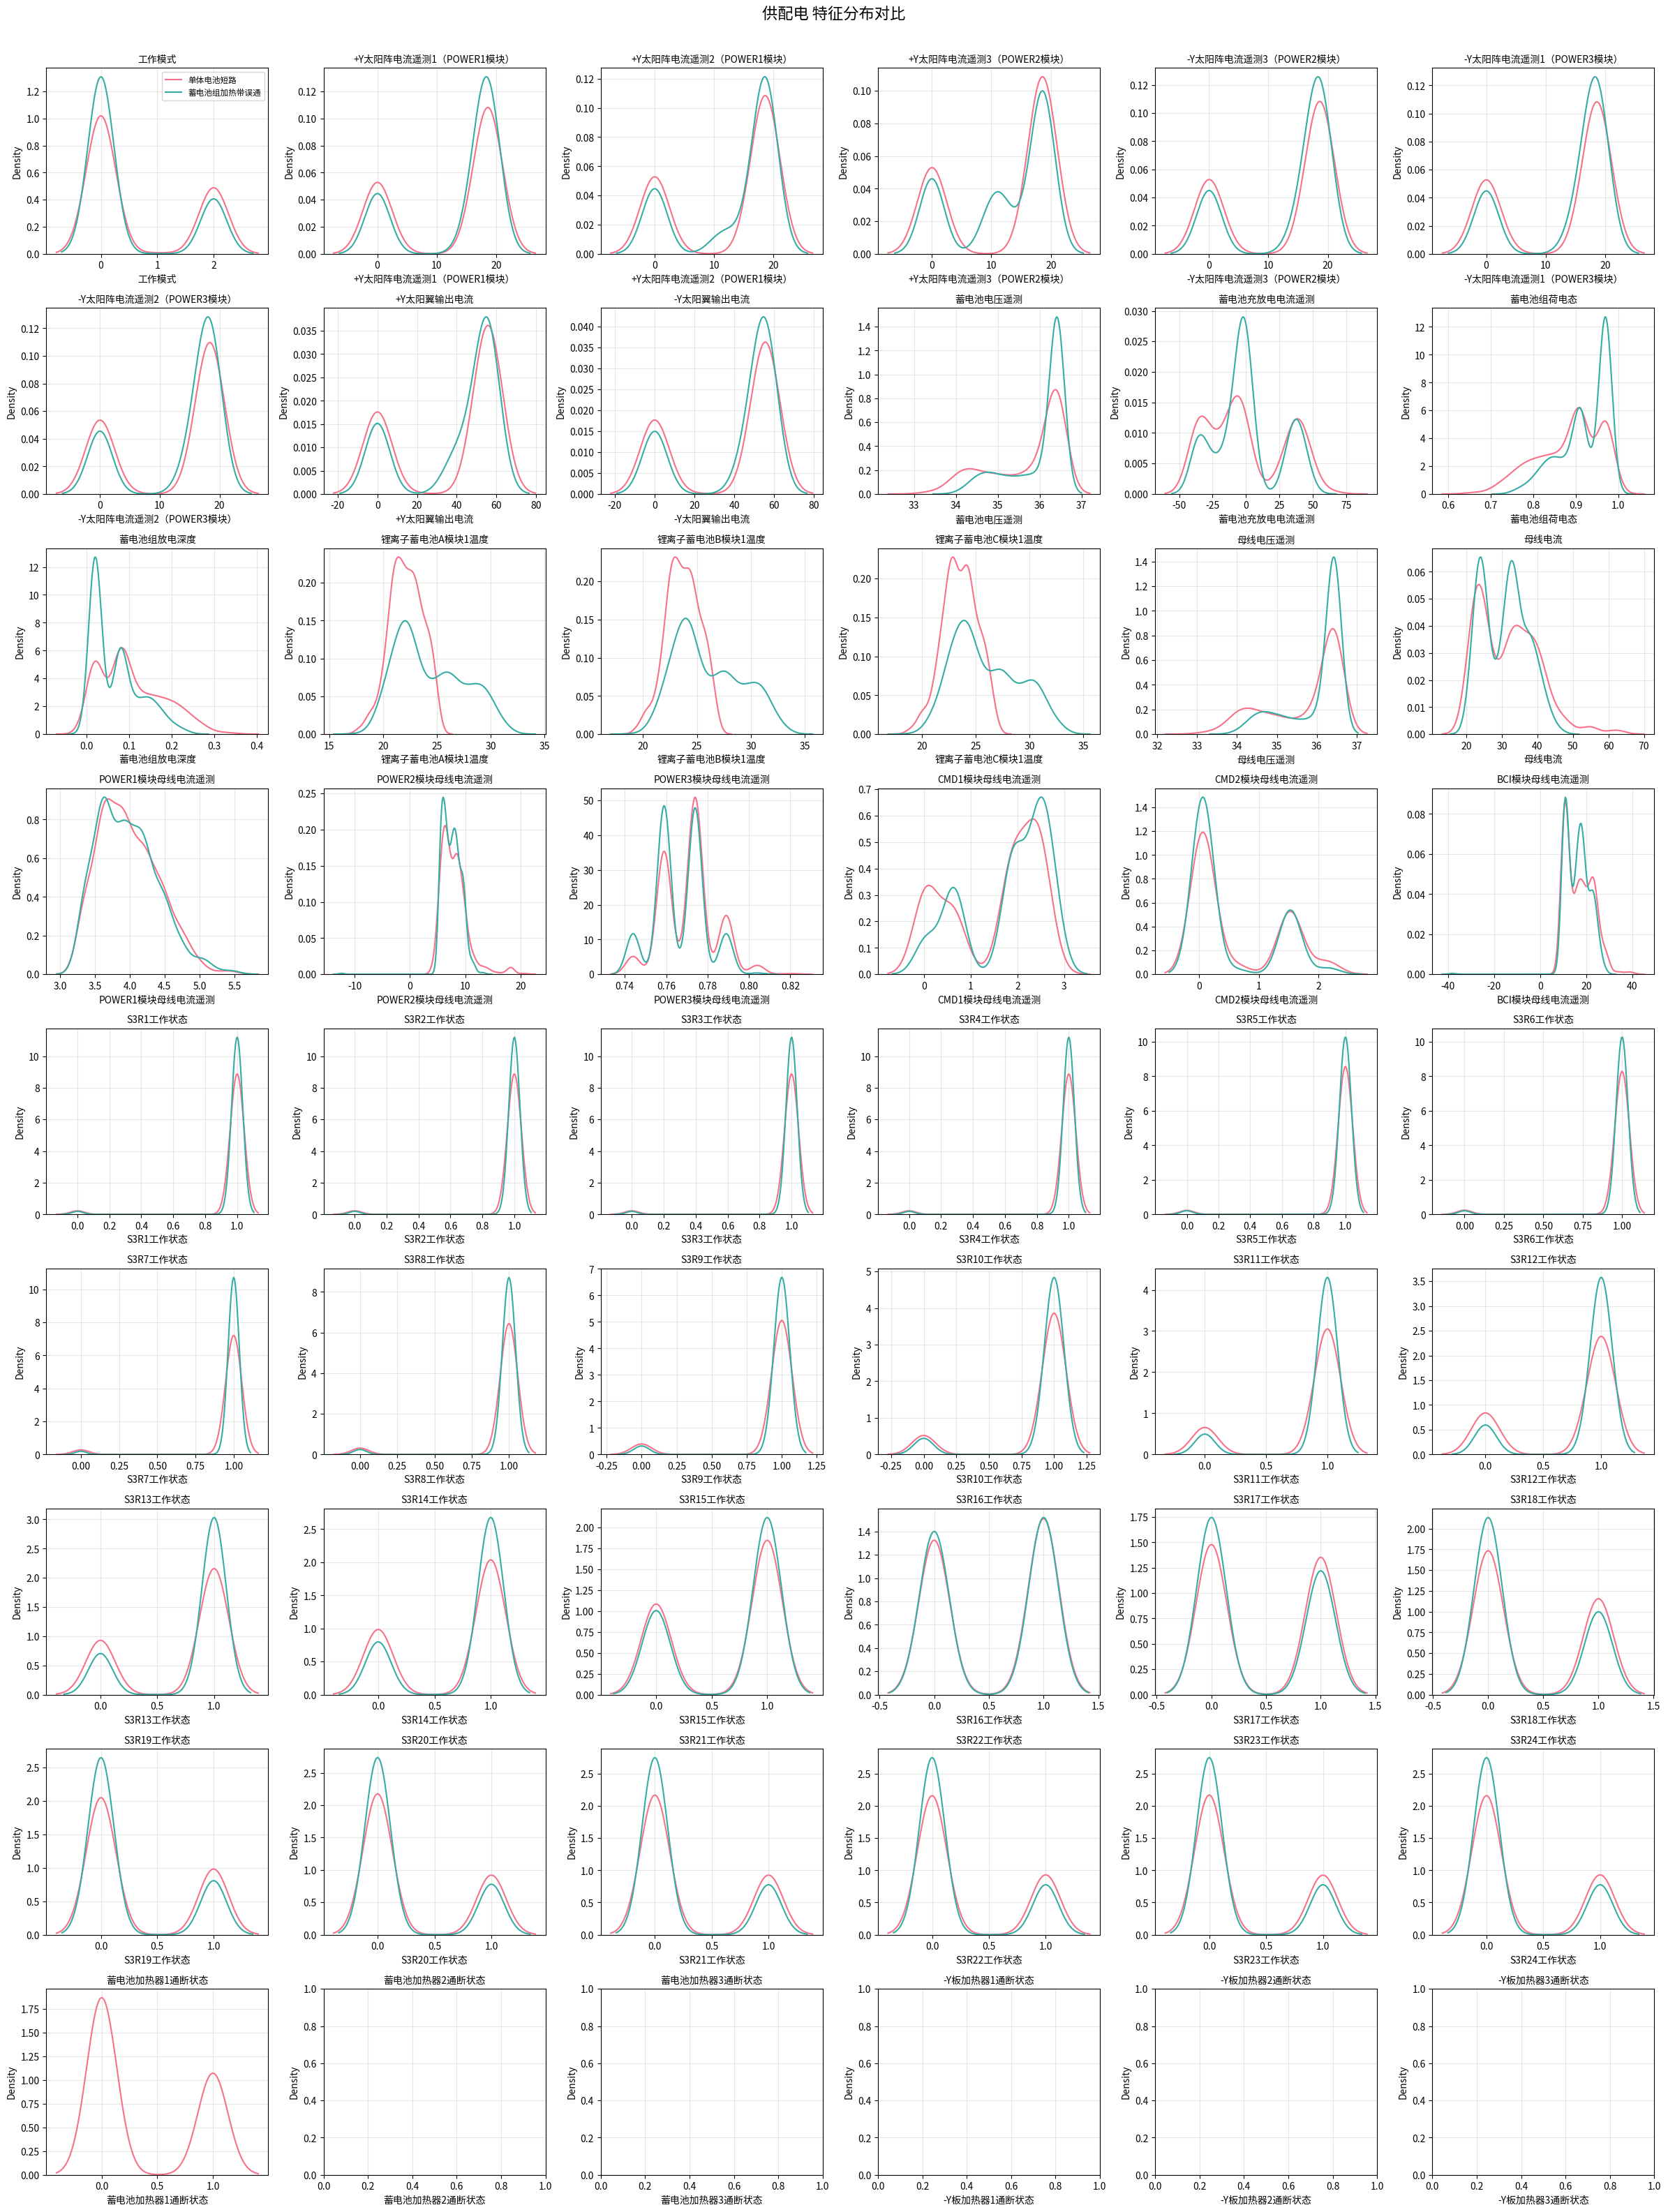


=== 可视化 姿轨控 数据集 ===
目标故障类型: ['负Y翼A轴故障', '陀螺2输出常零故障']


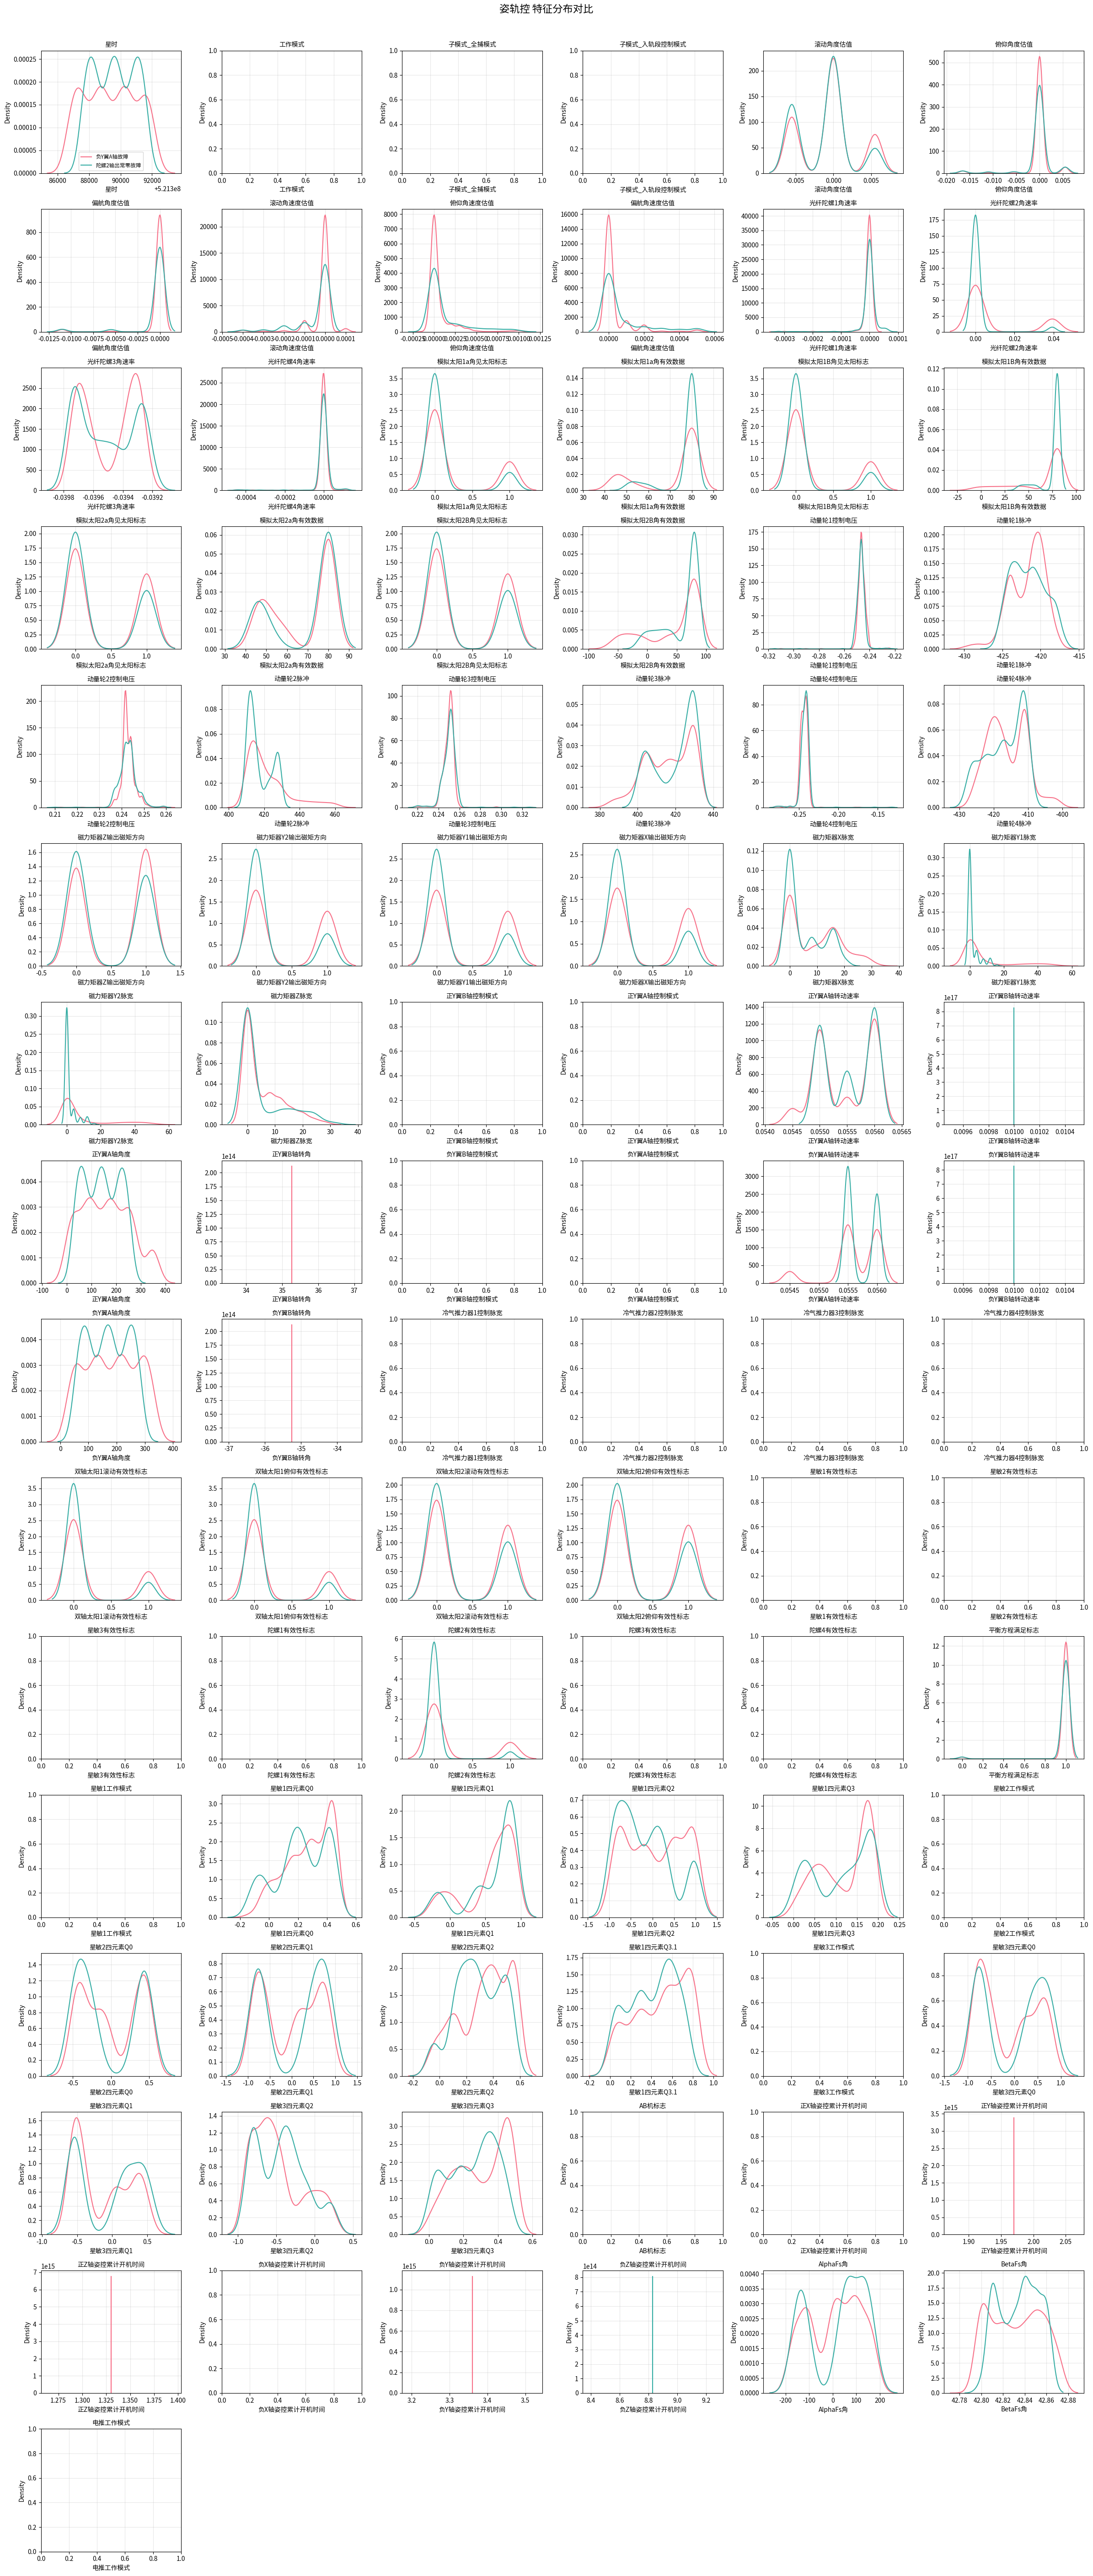

In [36]:
target_names = {
    "供配电" : ["单体电池短路", "蓄电池组加热带误通"],
    # "供配电" : ["单串电池片短路", "五串电池性能严重衰降"],
    "姿轨控" : ["负Y翼A轴故障", "陀螺2输出常零故障"],
}

for dataset_name, target_names_list in target_names.items():
    print(f"\n=== 可视化 {dataset_name} 数据集 ===")
    print(f"目标故障类型: {target_names_list}")
    data_path = dataset_paths[dataset_name]
    df = pd.read_csv(os.path.join(data_path, 'processed_all.csv'))
    visulize_target_label(df, dataset_name, target_fault_names=target_names_list)